# Classification of Handwritten Numbers (MNIST)
The task consists of two parts using different variants of the nearest-neighborhood classifier

## Part 1
The whole training set is used as templates

### a)

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
import time

In [62]:
# Load data from .mat file
data    = scipy.io.loadmat('data_all.mat')
trainv  = data['trainv'].astype(np.float32)   # (60000, 784)
trainlab = data['trainlab'].flatten().astype(int)
testv   = data['testv'].astype(np.float32)    # (10000, 784)
testlab  = data['testlab'].flatten().astype(int)

# Generate the confusion matrix
def generateConfMatrix(predicted_labels, true_labels):
    # 0-axis / y-axis: true class
    # 1-axis / x-axis: predicted class
    conf_matrix = np.zeros((10,10), dtype=int)

    for i in range(len(predicted_labels)):
        predicted_class = predicted_labels[i]        
        true_classs = true_labels[i]

        conf_matrix[true_classs][predicted_class] += 1
    
    return conf_matrix

# Calculate the precision, recall and accuracy
def calculatePerformance(conf_matrix):
    # Precision: correctly classified as class i / all classified as class i
    precision = np.diag(conf_matrix) / np.sum(conf_matrix, axis=0)
    # Recall: correctly classified as class i / all true class i
    recall = np.diag(conf_matrix) / np.sum(conf_matrix, axis=1)
    # Accuracy: correctly classified / all samples
    accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)
    return precision, recall, accuracy

# Generate a plt.Figure representation of the confusion matrix
def generateConfMatrixFigure(conf_matrix, title, figtitle = ""):
    confusionM_fig = plt.figure(figsize = (10,7))
    confusionM_fig = sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    
    _, _, accuracy = calculatePerformance(conf_matrix)
    confusionM_fig.set_title(f"{title}\nError rate: {1-accuracy:.2%}")

    confusionM_fig.set_ylabel("True class")
    confusionM_fig.set_xlabel("Predicted class")

    confusionM_fig.set_xticklabels(list(range(0, conf_matrix.shape[0])))
    confusionM_fig.set_yticklabels(list(range(0, conf_matrix.shape[0])))
    
    plt.savefig(f"figures/confmatrix_" + figtitle + ".pdf", format="pdf", bbox_inches="tight")
    return confusionM_fig


### kNN classifier

In [ ]:
# KNN implementation
def NNClassifier(data_to_be_classified, labeled_data, k):
    n_samples = data_to_be_classified.shape[0]
    block_size = 1000
    kNN_index = np.zeros((n_samples, k), dtype=int)

    # Precompute squared norms of templates(done once, outside the loop)
    tt = (labeled_data ** 2).sum(axis=1)

    for i in range(0, n_samples, block_size):
        q  = data_to_be_classified[i:i+block_size]
        qq = (q ** 2).sum(axis=1, keepdims=True)
        d2 = qq + tt - 2 * (q @ labeled_data.T)   # squared L2
        kNN_index[i:i+block_size] = np.argpartition(d2, kth=k, axis=1)[:, :k]

    return kNN_index


### Classify all samples using NN

In [ ]:
t0 = time.perf_counter()
kNN_index = NNClassifier(testv, trainv, k=1)
t1 = time.perf_counter()
print(f"Classified in {t1-t0:.1f}s")

NN_index = kNN_index[:, 0] # Returns only the index of the nearest neighbor
NN_pred = trainlab[NN_index]

Classified in 11.3s


### Display confusion matrix and error rates for NN classification

Accuracy: 96.91%
0: precision: 97.99%, recall: 99.29%
1: precision: 96.74%, recall: 99.47%
2: precision: 98.41%, recall: 96.12%
3: precision: 96.13%, recall: 96.04%
4: precision: 97.22%, recall: 96.13%
5: precision: 95.13%, recall: 96.41%
6: precision: 98.13%, recall: 98.54%
7: precision: 95.66%, recall: 96.50%
8: precision: 98.08%, recall: 94.46%
9: precision: 95.65%, recall: 95.84%


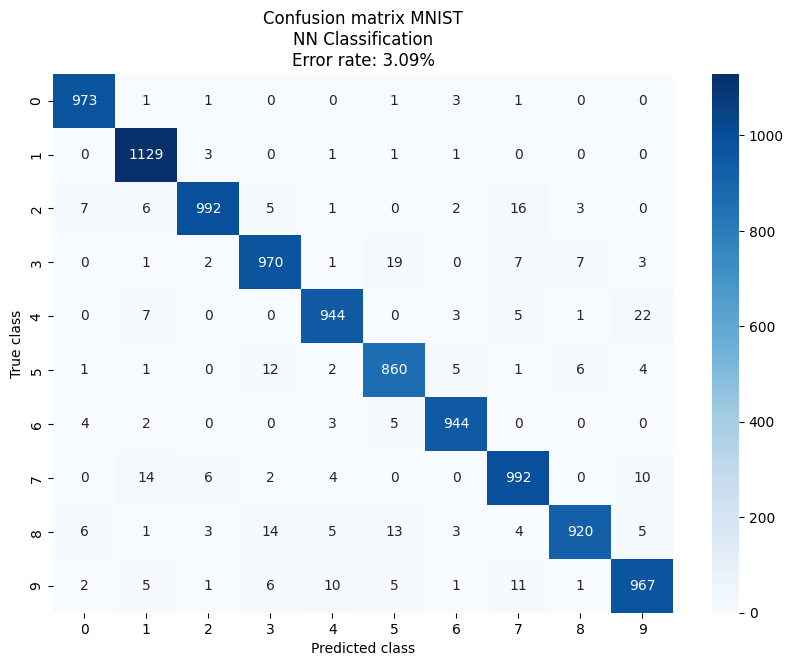

In [113]:
conf_matrix1 = generateConfMatrix(NN_pred, testlab)
generateConfMatrixFigure(conf_matrix1, "Confusion matrix MNIST\nNN Classification", "1a_NN_ConfMatrix")
precision, recall, accuracy = calculatePerformance(conf_matrix1)
print(f"Accuracy: {accuracy:.2%}")
for i in range(10):
    print(f"{i}: precision: {precision[i]:.2%}, recall: {recall[i]:.2%}")

### Display confusion matrix and error rates for NN classification with k=7

Classified in 13.3s
Accuracy: 95.76%
0: precision: 96.43%, recall: 99.08%
1: precision: 95.51%, recall: 99.30%
2: precision: 98.19%, recall: 94.38%
3: precision: 94.75%, recall: 94.75%
4: precision: 96.78%, recall: 94.81%
5: precision: 93.78%, recall: 94.62%
6: precision: 97.10%, recall: 97.91%
7: precision: 94.61%, recall: 95.53%
8: precision: 97.92%, recall: 91.89%
9: precision: 92.82%, recall: 94.85%


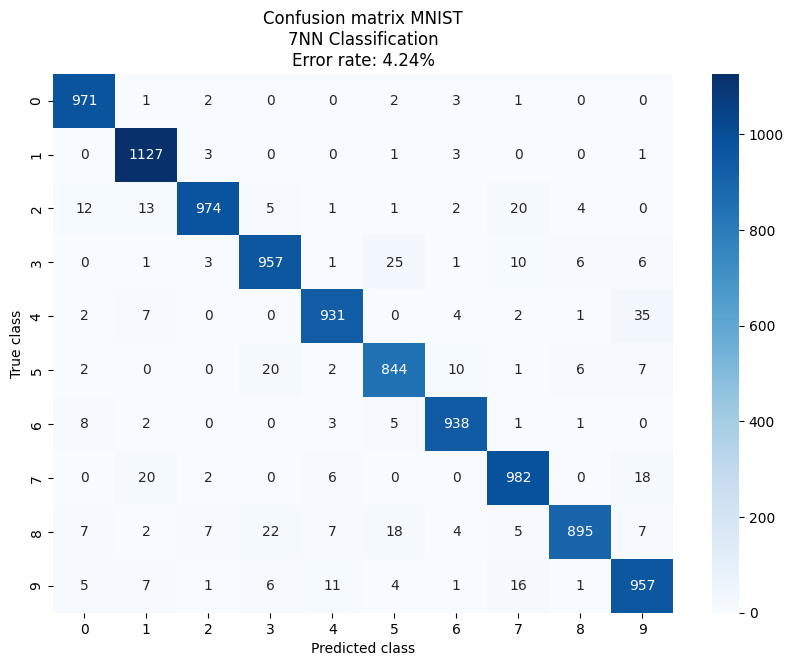

In [114]:
t0 = time.perf_counter()
kNN_index = NNClassifier(testv, trainv, k=7)
t1 = time.perf_counter()
print(f"Classified in {t1-t0:.1f}s") 

NN_index = kNN_index[:, 0] 
NN_pred = trainlab[NN_index]

conf_matrix2 = generateConfMatrix(NN_pred, testlab)
generateConfMatrixFigure(conf_matrix2, "Confusion matrix MNIST\n7NN Classification", "1a_7NN_ConfMatrix")
precision, recall, accuracy = calculatePerformance(conf_matrix2)
print(f"Accuracy: {accuracy:.2%}")
for i in range(10):
    print(f"{i}: precision: {precision[i]:.2%}, recall: {recall[i]:.2%}")

### b) Misclassified images 

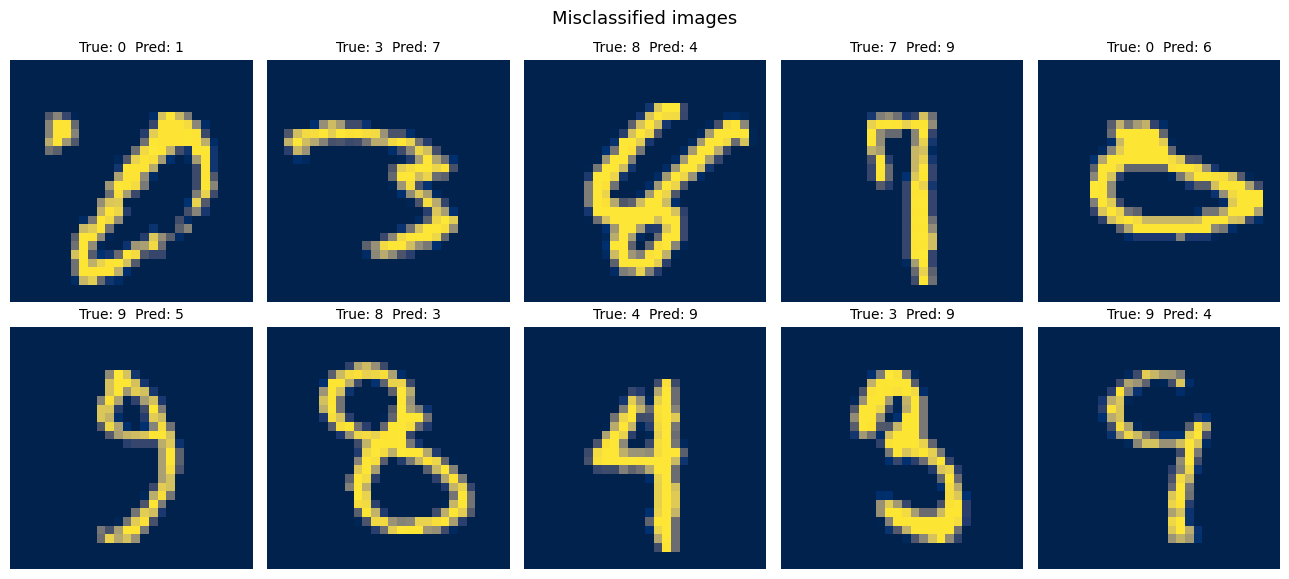

In [104]:
wrong_index = np.where(NN_pred != testlab)[0]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
np.random.seed(42)
sample = np.random.choice(wrong_index, size=10, replace=False)

for i, idx in enumerate(sample):
    axes.flat[i].imshow(testv[idx].reshape(28, 28), cmap='cividis')
    axes.flat[i].set_title(f'True: {testlab[idx]}  Pred: {NN_pred[idx]}', fontsize=10)
    axes.flat[i].axis('off')

plt.suptitle(f'Misclassified images', fontsize=13)
plt.tight_layout()
plt.savefig("figures/misclassified.pdf", format="pdf", bbox_inches="tight")
plt.show()

### c) Correctly classified images

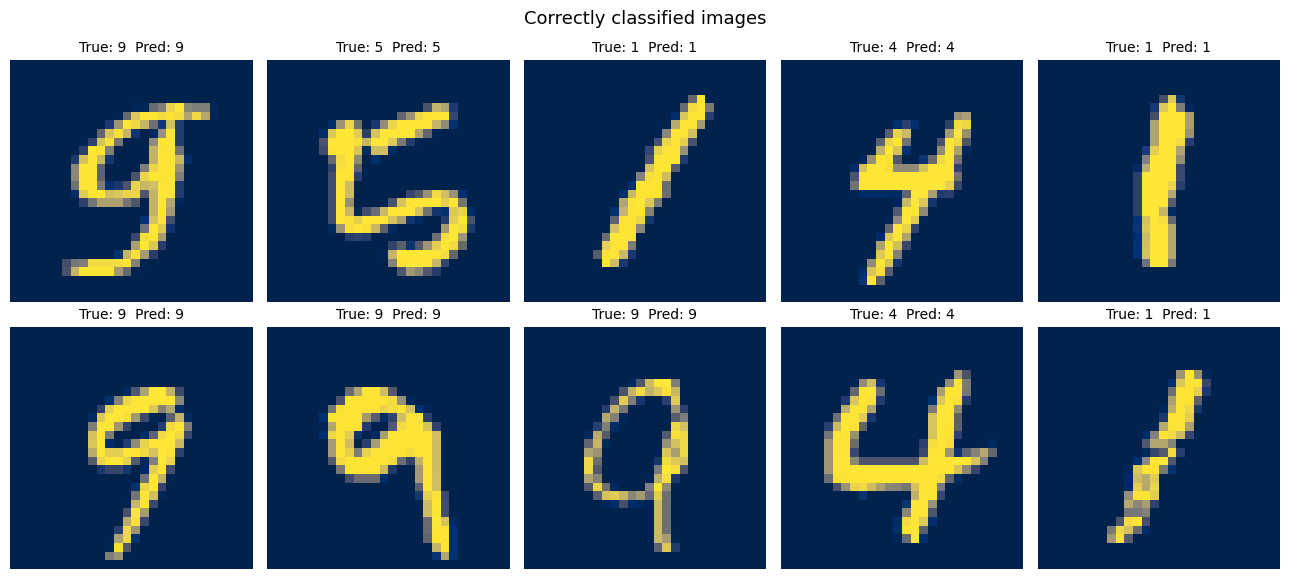

In [102]:
correct_index = np.where(NN_pred == testlab)[0]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
np.random.seed(42)
sample = np.random.choice(correct_index, size=10, replace=False)

for i, idx in enumerate(sample):
    axes.flat[i].imshow(testv[idx].reshape(28, 28), cmap='cividis')
    axes.flat[i].set_title(f'True: {testlab[idx]}  Pred: {NN_pred[idx]}', fontsize=10)
    axes.flat[i].axis('off')

plt.suptitle(f'Correctly classified images', fontsize=13)
plt.tight_layout()
plt.savefig("figures/correctly_classified.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Part 2

### a) KMeans clustering
Clustering on the 6000 training vectors for each class into M = 64 clusters.

In [115]:
M = 64 # Clusters per class
def kmeans_clustering(trainv, trainlab, M):
    all_templates = []
    all_template_labels = []

    for digit in range(10):
        index = np.where(trainlab == digit)[0]
        train_digit = trainv[index]

        print(f"Clustering class {digit} ({len(index)} samples)...", end=" ", flush=True)
        km = KMeans(n_clusters=M, random_state=42, n_init=3, max_iter=200)
        km.fit(train_digit)

        all_templates.append(km.cluster_centers_.astype(np.float32))
        all_template_labels.extend([digit] * M)
        print("done")

    all_templates = np.ascontiguousarray(np.vstack(all_templates))
    all_template_labels = np.array(all_template_labels)

    print(f"\nDone. Template set: {all_templates.shape}")
    return all_templates, all_template_labels

all_templates, all_template_labels = kmeans_clustering(trainv, trainlab, M)


Clustering class 0 (5923 samples)... done
Clustering class 1 (6742 samples)... done
Clustering class 2 (5958 samples)... done
Clustering class 3 (6131 samples)... done
Clustering class 4 (5842 samples)... done
Clustering class 5 (5421 samples)... done
Clustering class 6 (5918 samples)... done
Clustering class 7 (6265 samples)... done
Clustering class 8 (5851 samples)... done
Clustering class 9 (5949 samples)... done

Done. Template set: (640, 784)


### b) NN classifier on clustered data

Classification time: 0.15s
Accuracy: 95.59%
0:  precision: 97.17%,  recall: 98.27%
1:  precision: 96.99%,  recall: 99.47%
2:  precision: 96.47%,  recall: 95.35%
3:  precision: 96.44%,  recall: 93.96%
4:  precision: 95.75%,  recall: 94.09%
5:  precision: 95.21%,  recall: 95.85%
6:  precision: 96.89%,  recall: 97.49%
7:  precision: 94.77%,  recall: 93.39%
8:  precision: 94.77%,  recall: 94.87%
9:  precision: 91.33%,  recall: 92.86%


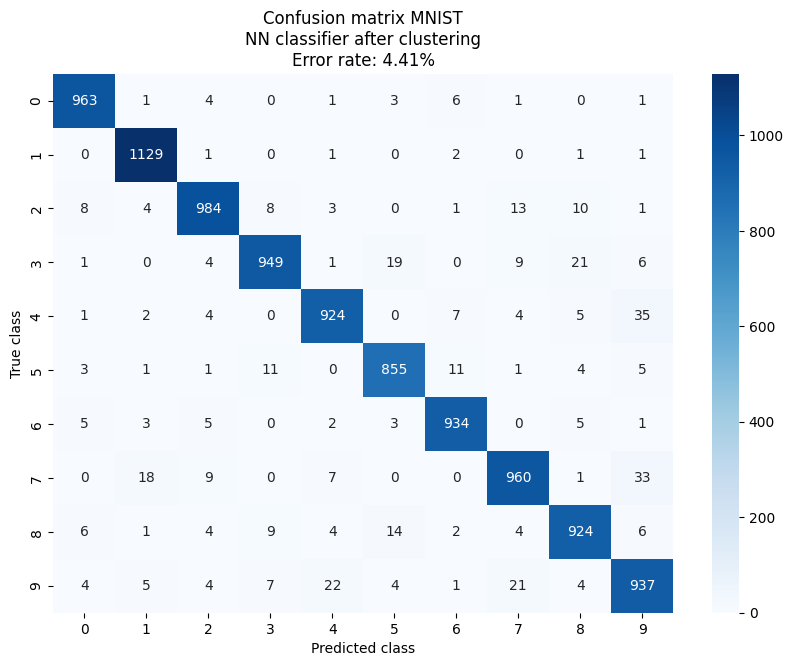

In [116]:
t0 = time.perf_counter()
kNN_index_kmeans = NNClassifier(testv, all_templates, k=1)
t1 = time.perf_counter()
print(f"Classification time: {t1-t0:.2f}s")

NN_pred_kmeans = all_template_labels[kNN_index_kmeans[:, 0]]

conf_matrix_km = generateConfMatrix(NN_pred_kmeans, testlab)
generateConfMatrixFigure(conf_matrix_km, "Confusion matrix MNIST\nNN classifier after clustering", "2b_kmeans_NN")

precision, recall, accuracy = calculatePerformance(conf_matrix_km)
print(f"Accuracy: {accuracy:.2%}")
for i in range(10):
    print(f"{i}:  precision: {precision[i]:.2%},  recall: {recall[i]:.2%}")

### c) KNN classifier with K = 7

Classification time: 0.17s
Accuracy: 93.30%
0:  precision: 95.30%,  recall: 97.35%
1:  precision: 92.84%,  recall: 99.38%
2:  precision: 95.25%,  recall: 91.38%
3:  precision: 92.57%,  recall: 93.76%
4:  precision: 91.87%,  recall: 92.06%
5:  precision: 91.89%,  recall: 92.71%
6:  precision: 95.92%,  recall: 95.72%
7:  precision: 93.88%,  recall: 90.95%
8:  precision: 93.25%,  recall: 89.32%
9:  precision: 90.32%,  recall: 89.69%


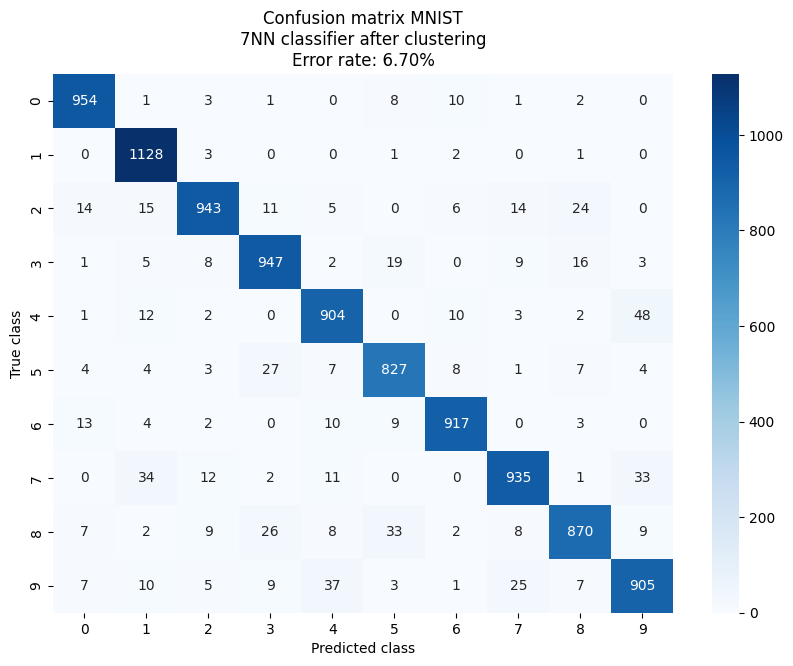

In [117]:
t0 = time.perf_counter()
kNN_index_k7  = NNClassifier(testv, all_templates, k=7)
t1 = time.perf_counter()
print(f"Classification time: {t1-t0:.2f}s")

kNN_labels  = all_template_labels[kNN_index_k7]             
KNN_pred_k7 = np.array([np.bincount(row, minlength=10).argmax() for row in kNN_labels])

conf_matrix_k7 = generateConfMatrix(KNN_pred_k7, testlab)
generateConfMatrixFigure(conf_matrix_k7, "Confusion matrix MNIST\n7NN classifier after clustering", "2c_kmeans_7NN")

precision, recall, accuracy = calculatePerformance(conf_matrix_k7)
print(f"Accuracy: {accuracy:.2%}")
for i in range(10):
    print(f"{i}:  precision: {precision[i]:.2%},  recall: {recall[i]:.2%}")